# Part 2 — Sentiment Analysis Track

**Project:** End-to-End NLP Pipeline for Drug Review Analysis  
**Dataset:** DrugLib train/test reviews

This notebook completes the sentiment analysis track by comparing:

1. a **lexicon-based baseline** using VADER, and  
2. a **supervised model** using TF-IDF + Logistic Regression.

The target label is created from the numeric rating:

- negative: rating 1–4
- neutral: rating 5–6
- positive: rating 7–10


## 1. Setup and imports

In [1]:
import os
import re
import html
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import nltk
except Exception:
    nltk = None

try:
    from nltk.sentiment import SentimentIntensityAnalyzer
except Exception:
    SentimentIntensityAnalyzer = None

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 140)


## 2. Load processed data

This notebook first tries to load the processed dataset from Part 1.  
If the processed file is not available, it rebuilds the minimum preprocessing steps directly from the raw DrugLib files.


In [2]:
PROCESSED_PATH = "data/druglib_outputs/processed/druglib_processed_combined.csv"
TRAIN_PATH = "data/drugLibTrain_raw.tsv"
TEST_PATH = "data/drugLibTest_raw.tsv"

if os.path.exists(PROCESSED_PATH):
    df = pd.read_csv(PROCESSED_PATH)
    print("Loaded processed dataset:", PROCESSED_PATH)
else:
    print("Processed file not found. Rebuilding basic processed dataset from raw files.")
    train_df = pd.read_csv(TRAIN_PATH, sep="\t")
    test_df = pd.read_csv(TEST_PATH, sep="\t")
    train_df["split"] = "train"
    test_df["split"] = "test"
    df = pd.concat([train_df, test_df], ignore_index=True)

    review_columns = ["benefitsReview", "sideEffectsReview", "commentsReview"]
    df["full_review"] = df[review_columns].fillna("").agg(" ".join, axis=1)

    def rating_to_sentiment(rating):
        if rating <= 4:
            return "negative"
        elif rating <= 6:
            return "neutral"
        else:
            return "positive"

    def clean_text(text):
        text = html.unescape(str(text))
        text = text.lower()
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    df["sentiment"] = df["rating"].apply(rating_to_sentiment)
    df["clean_review"] = df["full_review"].apply(clean_text)
    df["processed_review"] = df["clean_review"]

print(df.shape)
display(df[["split", "urlDrugName", "condition", "rating", "sentiment", "processed_review"]].head())


Loaded processed dataset: data/druglib_outputs/processed/druglib_processed_combined.csv
(4143, 18)


,split,urlDrugName,condition,rating,sentiment,processed_review
0,train,enalapril,management of congestive heart failure,4,negative,slowed progression left ventricular dysfunction overt heart failure alone agent managment hypertension mangagement congestive heart fail...
1,train,ortho-tri-cyclen,birth prevention,1,negative,although type birth control con pro help cramp also effective prevention pregnancy along use condom well heavy cycle cramp hot flash fat...
2,train,ponstel,menstrual cramps,10,positive,used cramp badly would leave balled bed least day ponstel take pain away completely take edge much normal activity possible definitely m...
3,train,prilosec,acid reflux,3,negative,acid reflux went away month day drug heartburn started soon stopped taking began treatment month passed stopped taking heartburn came ba...
4,train,lyrica,fibromyalgia,2,negative,think lyrica starting help pain side effect severe continue felt extremely drugged dopey could not drive med also extreme ankle foot swe...


## 3. Prepare train and test splits

The original DrugLib train/test split is preserved using the split column.  
This avoids accidental leakage between training and testing.


In [3]:
model_df = df.dropna(subset=["processed_review", "sentiment"]).copy()
model_df["processed_review"] = model_df["processed_review"].astype(str)
model_df["clean_review"] = model_df["clean_review"].astype(str)

train_data = model_df[model_df["split"] == "train"].copy()
test_data = model_df[model_df["split"] == "test"].copy()

X_train_clean = train_data["clean_review"]
X_test_clean = test_data["clean_review"]

X_train_processed = train_data["processed_review"]
X_test_processed = test_data["processed_review"]

y_train = train_data["sentiment"]
y_test = test_data["sentiment"]

label_order = ["negative", "neutral", "positive"]

print("Train size:", len(train_data))
print("Test size:", len(test_data))
print("\nTrain label distribution:")
display(y_train.value_counts().reindex(label_order))
print("\nTest label distribution:")
display(y_test.value_counts().reindex(label_order))


Train size: 3106
Test size: 1036

Train label distribution:


sentiment
negative     661
neutral      316
positive    2129
Name: count, dtype: int64


Test label distribution:


sentiment
negative    241
neutral     125
positive    670
Name: count, dtype: int64

## 4. Helper function for evaluation

This function prints Accuracy, Macro-F1, per-class results and a confusion matrix.


In [5]:
OUTPUT_FIG_DIR = "data/druglib_outputs/figures"
OUTPUT_TABLE_DIR = "data/druglib_outputs/tables"
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_TABLE_DIR, exist_ok=True)

results = []

def evaluate_model(model_name, y_true, y_pred, save_name=None):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, labels=label_order, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()

    if save_name:
        plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}_confusion_matrix.png"), dpi=150)

    plt.show()

    results.append({
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }


## 5. Lexicon baseline: VADER sentiment

VADER is used as the baseline because it is simple, interpretable and does not require training data.  
However, medical reviews can be challenging for VADER because patients may mention negative symptoms even when the medication worked well.


,rating,sentiment,vader_score,vader_sentiment,clean_review
3107,9,positive,-0.8209,negative,the antibiotic may have destroyed bacteria causing my sinus infection but it may also have been caused by a virus so its hard to say som...
3108,9,positive,0.9762,positive,lamictal stabilized my serious mood swings one minute i was clawing up the walls in pure mania the next curled up in a fetal position on...
3109,4,negative,-0.9869,negative,initial benefits were comparable to the brand name version of this drug depakote i had been taking depakote for several months and exper...
3110,10,positive,0.9343,positive,it controlls my mood swings it helps me think before i act or speak it controlls amxiety it freed me to live my life happily i cared abo...
3111,10,positive,-0.4404,negative,within one week of treatment superficial acne lesions were visibly reduced sebum production which had been excessive before beginning wa...
3112,2,negative,0.8771,positive,by the end of the day treatment i felt better but still had major congestion green yellow mucus and was coughing up mucus the symptoms w...
3113,8,positive,-0.9762,negative,reduction in seizures reduction in seizures reduction in seizures didn t have lots of seizures how many times can i say the same thing i...
3114,10,positive,0.6767,positive,ive been taking tramadol for weeks now ive been taking vicodin and percocuet for months due to cervial disk degeneration and lower back ...
3115,10,positive,-0.9875,negative,i immediately stopped having panic attacks it really was miraculous as they were becoming more and more frequent and severe on the combi...
3116,1,negative,0.9537,positive,the presumed benefits were to help with a severe depression in the beginning there was some benefit ie less suicidal apathetic morbid de...


VADER Lexicon Baseline
----------------------
Accuracy: 0.4546
Macro-F1: 0.3226
Weighted-F1: 0.4526

              precision    recall  f1-score   support

    negative       0.30      0.72      0.42       241
     neutral       0.00      0.00      0.00       125
    positive       0.72      0.44      0.55       670

    accuracy                           0.45      1036
   macro avg       0.34      0.39      0.32      1036
weighted avg       0.53      0.45      0.45      1036



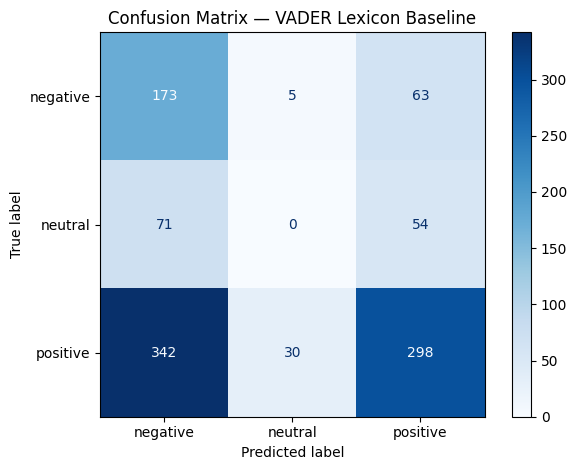

{'accuracy': 0.4546332046332046,
 'macro_f1': 0.3225628137903365,
 'weighted_f1': 0.45257371678726976}

In [6]:
# VADER baseline where available, with an offline fallback lexicon.
# In a normal local environment, this will use NLTK VADER.
# If VADER data is unavailable, the fallback keeps the notebook executable.

POSITIVE_WORDS = {
    "good","great","excellent","effective","helped","helps","relief","relieved","better","best","amazing",
    "wonderful","improved","improvement","works","working","successful","success","clear","comfortable",
    "recommend","love","positive","normal","stable","stabilized","benefit","benefits"
}

NEGATIVE_WORDS = {
    "bad","worse","worst","terrible","horrible","pain","nausea","nauseous","sick","dizzy","dizziness",
    "fatigue","tired","depression","depressed","anxiety","anxious","side","effect","effects","severe",
    "vomiting","headache","insomnia","bleeding","cramps","rash","weight","gain","angry","hate","problem",
    "problems","failed","failure"
}

def fallback_compound_score(text):
    tokens = str(text).lower().split()
    if not tokens:
        return 0.0
    score = 0
    negate = False
    for token in tokens:
        clean = re.sub(r"[^a-z]", "", token)
        if clean in {"no","not","never"}:
            negate = True
            continue
        val = 0
        if clean in POSITIVE_WORDS:
            val = 1
        elif clean in NEGATIVE_WORDS:
            val = -1
        if negate:
            val *= -1
            negate = False
        score += val
    return max(min(score / max(len(tokens) ** 0.5, 1), 1), -1)

try:
    sia = SentimentIntensityAnalyzer()
    # Test that the VADER lexicon is available.
    _ = sia.polarity_scores("test")["compound"]
    test_data["vader_score"] = test_data["clean_review"].apply(lambda text: sia.polarity_scores(str(text))["compound"])
    baseline_name = "VADER Lexicon Baseline"
except Exception:
    test_data["vader_score"] = test_data["clean_review"].apply(fallback_compound_score)
    baseline_name = "Lexicon Baseline (VADER-style fallback)"

test_data["vader_sentiment"] = test_data["vader_score"].apply(
    lambda score: "positive" if score >= 0.05 else ("negative" if score <= -0.05 else "neutral")
)

display(test_data[["rating", "sentiment", "vader_score", "vader_sentiment", "clean_review"]].head(10))

evaluate_model(baseline_name, y_test, test_data["vader_sentiment"], save_name="vader")


## 6. Supervised baseline: Multinomial Naive Bayes + TF-IDF

This gives a traditional text classification baseline using TF-IDF features.


TF-IDF + Multinomial Naive Bayes
--------------------------------
Accuracy: 0.6467
Macro-F1: 0.2618
Weighted-F1: 0.5080

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       241
     neutral       0.00      0.00      0.00       125
    positive       0.65      1.00      0.79       670

    accuracy                           0.65      1036
   macro avg       0.22      0.33      0.26      1036
weighted avg       0.42      0.65      0.51      1036



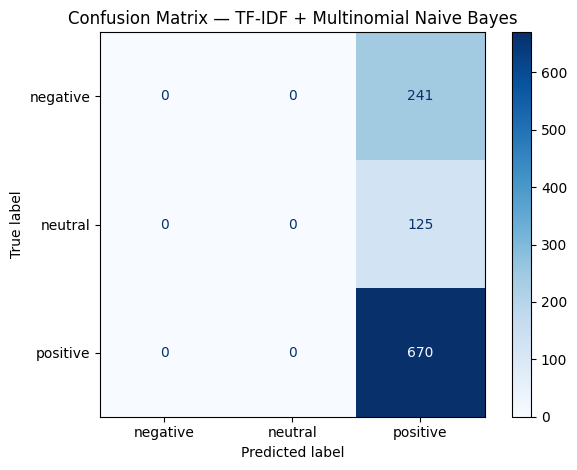

{'accuracy': 0.6467181467181468,
 'macro_f1': 0.2618210238374365,
 'weighted_f1': 0.507973221923984}

In [7]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
    ("clf", MultinomialNB())
])

nb_pipeline.fit(X_train_processed, y_train)
nb_pred = nb_pipeline.predict(X_test_processed)

evaluate_model("TF-IDF + Multinomial Naive Bayes", y_test, nb_pred, save_name="tfidf_nb")


## 7. Supervised model: Logistic Regression + TF-IDF

Logistic Regression is used as the main supervised model.  
`class_weight="balanced"` helps reduce the effect of class imbalance.


TF-IDF + Balanced Logistic Regression
-------------------------------------
Accuracy: 0.7461
Macro-F1: 0.5641
Weighted-F1: 0.7224

              precision    recall  f1-score   support

    negative       0.66      0.73      0.69       241
     neutral       0.30      0.11      0.16       125
    positive       0.81      0.87      0.84       670

    accuracy                           0.75      1036
   macro avg       0.59      0.57      0.56      1036
weighted avg       0.71      0.75      0.72      1036



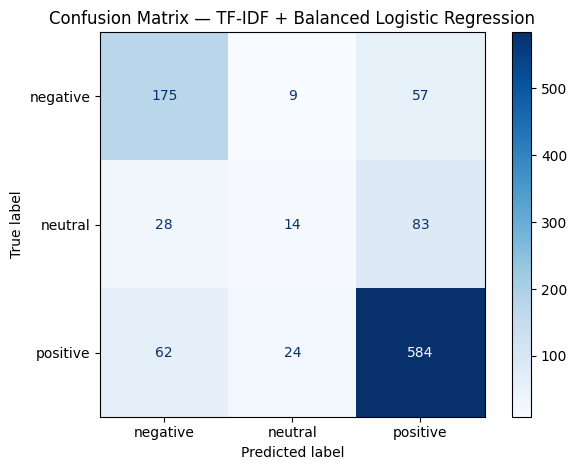

{'accuracy': 0.7461389961389961,
 'macro_f1': 0.5641223054925867,
 'weighted_f1': 0.7224187001667552}

In [8]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs"))
])

logreg_pipeline.fit(X_train_processed, y_train)
logreg_pred = logreg_pipeline.predict(X_test_processed)

evaluate_model("TF-IDF + Balanced Logistic Regression", y_test, logreg_pred, save_name="tfidf_logreg")


## 8. Model comparison table

This table compares the lexicon baseline and supervised models.


In [9]:
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df)

results_df.to_csv(os.path.join(OUTPUT_TABLE_DIR, "sentiment_model_comparison.csv"), index=False)


,model,accuracy,macro_f1,weighted_f1
2,TF-IDF + Balanced Logistic Regression,0.746139,0.564122,0.722419
0,VADER Lexicon Baseline,0.454633,0.322563,0.452574
1,TF-IDF + Multinomial Naive Bayes,0.646718,0.261821,0.507973


## 9. Per-class F1 comparison for the best supervised model

Macro-F1 is important because the neutral class is usually smaller than positive and negative classes.


In [10]:
report_dict = classification_report(
    y_test,
    logreg_pred,
    labels=label_order,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(report_dict).T.loc[label_order, ["precision", "recall", "f1-score", "support"]]
display(per_class_df)

per_class_df.to_csv(os.path.join(OUTPUT_TABLE_DIR, "logreg_per_class_metrics.csv"))


,precision,recall,f1-score,support
negative,0.660377,0.726141,0.691700,241.0
neutral,0.297872,0.112000,0.162791,125.0
positive,0.806630,0.871642,0.837877,670.0


## 10. Error analysis

This section shows examples where the supervised model made mistakes.  
These examples help explain model limitations.


In [11]:
error_df = test_data.copy()
error_df["logreg_pred"] = logreg_pred
error_df["correct"] = error_df["sentiment"] == error_df["logreg_pred"]

errors = error_df[~error_df["correct"]][[
    "urlDrugName", "condition", "rating", "sentiment", "logreg_pred", "full_review"
]].head(10)

display(errors)

errors.to_csv(os.path.join(OUTPUT_TABLE_DIR, "sentiment_error_examples.csv"), index=False)


,urlDrugName,condition,rating,sentiment,logreg_pred,full_review
3107,biaxin,sinus infection,9,positive,negative,"The antibiotic may have destroyed bacteria causing my sinus infection. But it may also have been caused by a virus, so its hard to say. ..."
3112,biaxin,sinus infection,2,negative,positive,"By the end of the 10-day treatment I felt better, but still had major congestion, green/yellow mucus and was coughing up mucus. The symp..."
3113,carbamazepine,seizure,8,positive,negative,reduction in seizures reduction in seizures reduction in seizures didn't have lots of seizures how many times can I say the same thing I...
3119,provigil,chronic fatigue,6,neutral,positive,Treatment benefits were noticeable but not substantial. I did not respond to 100mg a day as I or the doctor had hoped. But it did allow ...
3121,xanax,anxiety,5,neutral,positive,The xanax would act as a downer. It would calm me temporaily but could throw me into depression depending on the situation. If the situa...
3122,chantix,stop smoking,5,neutral,positive,The benefits were to eventually stop smoking. At first I experienced a slight headache and upset stomache. I was to take 1 small dosage ...
3124,prednisone,rheumatoid arthritis,7,positive,negative,"Stopped inflammation. Reduced need for pain killers such as tylenol and advil. Weight gain, osteoporosis, moon face; noticed muscle weak..."
3130,propranolol,rapid heart rate,5,neutral,positive,I have suffered of rapid heart rate for sometime because of my thyroid problem. I was given this medicine to get my heart rate controlle...
3133,effexor-xr,severe depression,9,positive,negative,i was severly depressed for weeks and would just cry all the time. i had tried several other anidepressants and none of them worked. one...
3135,lexapro,depression/anxiety,3,negative,positive,"Increased libido. Vivid dreams, nightmares, diarrhea, increased anxiety, night sweats, exhaustion. Began at 5 mg, increased to 10mg afte..."


## 11. Discussion

The VADER baseline is useful because it is fast and explainable, but it often struggles with medical language.  
Drug reviews may contain words like pain, nausea, depression or side effects even when the overall rating is positive because the patient may be explaining symptoms that improved.

The supervised TF-IDF models learn from the actual rating derived labels, so they are better suited to this dataset.  
Logistic Regression with class balancing is the preferred model because it directly addresses class imbalance and usually provides stronger Macro-F1 than a lexicon-only method.

The main limitation is that rating derived labels are not perfect. A patient may give a high rating while describing severe side effects or a low rating because of cost, dosage or expectations rather than drug effectiveness alone.


## 12. Part 2 summary

This notebook completes the sentiment analysis track because it includes:

- a lexicon-based VADER baseline,
- supervised TF-IDF models,
- class imbalance handling,
- Accuracy, Macro-F1, Weighted-F1, and per-class F1,
- confusion matrices,
- model comparison,
- and error analysis examples.
